# HATR su dataset interi: River vs CapyMOA

Configurazione `adaptive`, no bootstrap su Bike (17 379 istanze), Fried (40 768) e HyperPlaneRegression (50 000) in prequential evaluation. Metriche: MAE e R² cumulativi.

## Setup

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import jpype
import jpype.config
jpype.config.destroy_jvm = False

HATR_JAR = os.path.normpath(os.path.join(
    os.getcwd(), '..', 'implementation',
    'hatr-moa', 'target',
    'hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar'))
assert os.path.exists(HATR_JAR), (
    f'JAR non trovato: {HATR_JAR}\n'
    'compilare: cd implementation/hatr-moa && mvn package -DskipTests')

if jpype.isJVMStarted():
    print('JVM già avviata — Kernel → Restart & Run All')
else:
    os.environ["CAPYMOA_JVM_ARGS"] = "-Xmx8g -Xss10M -XX:ErrorFile=/dev/null"
    jpype.addClassPath(HATR_JAR)

from capymoa.datasets import Bike, Fried
from capymoa.stream.generator import HyperPlaneRegression

import utils   # importato dopo JVM: gestisce sys.path, capymoa, river, hatr_capymoa

print('Setup OK')

Setup OK


## Dataset

In [2]:
HYPER_N  = 50_000

import urllib.request, gzip, shutil

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), 'data'))
os.makedirs(DATA_DIR, exist_ok=True)

_ELEC_PATH = os.path.join(DATA_DIR, 'electricity.arff')
_ELEC_URL  = 'https://www.dropbox.com/scl/fi/p7btran9xdas20neva917/electricity.arff.gz?rlkey=xt8hc6542b8wr01eitcw7mwpz&st=paqojdax&dl=1'
if not os.path.exists(_ELEC_PATH):
    print('Downloading electricity.arff...')
    _gz = _ELEC_PATH + '.gz'
    urllib.request.urlretrieve(_ELEC_URL, _gz)
    with gzip.open(_gz, 'rb') as _f_in, open(_ELEC_PATH, 'wb') as _f_out:
        shutil.copyfileobj(_f_in, _f_out)
    os.remove(_gz)
    print('Done.')

datasets = {}
datasets['Bike']             = utils.materialize_stream(Bike())
datasets['Fried']            = utils.materialize_stream(Fried())
datasets['Hyper']            = utils.materialize_stream(
    HyperPlaneRegression(
        instance_random_seed=1, number_of_attributes=10,
        number_of_drifting_attributes=2, magnitude_of_change=0.001,
        noise_percentage=5),
    max_instances=HYPER_N)
datasets['HyperFast']        = utils.materialize_stream(
    HyperPlaneRegression(
        instance_random_seed=1, number_of_attributes=10,
        number_of_drifting_attributes=5, magnitude_of_change=0.1,
        noise_percentage=10),
    max_instances=HYPER_N)
datasets['FriedDrift']       = utils.make_fried_drift()
datasets['RBFReg']           = utils.make_rbf_regression()
datasets['ElectricityDemand'] = utils.load_electricity_demand(
    os.path.join(DATA_DIR, 'electricity.arff'))

for name, (X, y, _) in datasets.items():
    print(f'{name:<20}  n={len(X):>6}  feat={X.shape[1]:>2}  '
          f'y∈[{y.min():.2f}, {y.max():.2f}]')

Bike                  n= 17379  feat=12  y∈[1.00, 977.00]
Fried                 n= 40768  feat=10  y∈[-1.23, 30.52]
Hyper                 n= 50000  feat=10  y∈[56.28, 677.42]
HyperFast             n= 50000  feat=10  y∈[-16481.32, 71348.53]
FriedDrift            n= 40000  feat=10  y∈[-1.45, 29.77]
RBFReg                n= 30000  feat=10  y∈[-15.46, 16.23]
ElectricityDemand     n= 45312  feat= 7  y∈[0.00, 1.00]


In [3]:
import pandas as pd
import re

def _feat_names(schema, n):
    attrs = re.findall(
        r'@attribute\s+(\S+)\s+({[^}]+}|\S+)',
        str(schema), re.IGNORECASE)
    if len(attrs) >= n:
        return [f'{name} ({"nom" if typ.startswith("{") else "num"})'
                for name, typ in attrs[:n]]
    return [f'x{i}' for i in range(n)]

for name, (X, y, schema) in datasets.items():
    print(f"\n{'='*60}")
    print(f"  {name}  —  {len(X)} istanze, {X.shape[1]} feature")
    print(f"  schema: {schema}")
    cols = _feat_names(schema, X.shape[1])
    df = pd.DataFrame(X[:5], columns=cols)
    df['[y]'] = y[:5]
    display(df.round(4))



  Bike  —  17379 istanze, 12 feature
  schema: @relation bike-share-hour_transform_1

@attribute season numeric
@attribute yr numeric
@attribute mth numeric
@attribute hr numeric
@attribute holiday numeric
@attribute weekday numeric
@attribute workingday numeric
@attribute weathersit numeric
@attribute temp numeric
@attribute atemp numeric
@attribute hum numeric
@attribute windspeed numeric
@attribute cnt numeric

@data


,season (num),yr (num),mth (num),hr (num),holiday (num),weekday (num),workingday (num),weathersit (num),temp (num),atemp (num),hum (num),windspeed (num),[y]
0,1.0,0.0,1.0,0.0,0.0,6.0,0.0,1.0,0.24,0.2879,0.81,0.0,16.0
1,1.0,0.0,1.0,1.0,0.0,6.0,0.0,1.0,0.22,0.2727,0.80,0.0,40.0
2,1.0,0.0,1.0,2.0,0.0,6.0,0.0,1.0,0.22,0.2727,0.80,0.0,32.0
3,1.0,0.0,1.0,3.0,0.0,6.0,0.0,1.0,0.24,0.2879,0.75,0.0,13.0
4,1.0,0.0,1.0,4.0,0.0,6.0,0.0,1.0,0.24,0.2879,0.75,0.0,1.0



  Fried  —  40768 istanze, 10 feature
  schema: @relation data_res_fried.

@attribute attr_0 numeric
@attribute attr_1 numeric
@attribute attr_2 numeric
@attribute attr_3 numeric
@attribute attr_4 numeric
@attribute attr_5 numeric
@attribute attr_6 numeric
@attribute attr_7 numeric
@attribute attr_8 numeric
@attribute attr_9 numeric
@attribute target numeric

@data


,attr_0 (num),attr_1 (num),attr_2 (num),attr_3 (num),attr_4 (num),attr_5 (num),attr_6 (num),attr_7 (num),attr_8 (num),attr_9 (num),[y]
0,0.487,0.072,0.004,0.833,0.765,0.600,0.132,0.886,0.073,0.342,17.949
1,0.223,0.401,0.659,0.528,0.843,0.713,0.580,0.473,0.572,0.528,13.815
2,0.903,0.913,0.940,0.979,0.561,0.744,0.627,0.818,0.309,0.510,20.766
3,0.791,0.857,0.359,0.844,0.155,0.948,0.114,0.292,0.412,0.991,18.301
4,0.326,0.593,0.085,0.927,0.926,0.633,0.431,0.326,0.031,0.730,22.989



  Hyper  —  50000 istanze, 10 feature
  schema: @relation 'generators.HyperplaneGeneratorForRegression -t 0.001'

@attribute att1 numeric
@attribute att2 numeric
@attribute att3 numeric
@attribute att4 numeric
@attribute att5 numeric
@attribute att6 numeric
@attribute att7 numeric
@attribute att8 numeric
@attribute att9 numeric
@attribute att10 numeric
@attribute target numeric

@data


...

,x0 (num),x1 (num),x2 (num),x3 (num),x4 (num),x5 (num),x6 (num),x7 (num),x8 (num),x9 (num),[y]
0,0.3745,0.9507,0.7320,0.5987,0.1560,0.1560,0.0581,0.8662,0.6011,0.7081,16.5067
1,0.0206,0.9699,0.8324,0.2123,0.1818,0.1834,0.3042,0.5248,0.4319,0.2912,6.5694
2,0.6119,0.1395,0.2921,0.3664,0.4561,0.7852,0.1997,0.5142,0.5924,0.0465,8.4661
3,0.6075,0.1705,0.0651,0.9489,0.9656,0.8084,0.3046,0.0977,0.6842,0.4402,21.1333
4,0.1220,0.4952,0.0344,0.9093,0.2588,0.6625,0.3117,0.5201,0.5467,0.1849,17.8251



  RBFReg  —  30000 istanze, 10 feature
  schema: @relation rbf_regression

@attribute x0 numeric
@attribute x1 numeric
@attribute x2 numeric
@attribute x3 numeric
@attribute x4 numeric
@attribute x5 numeric
@attribute x6 numeric
@attribute x7 numeric
@attribute x8 numeric
@attribute x9 numeric
@attribute y numeric

@data


,x0 (num),x1 (num),x2 (num),x3 (num),x4 (num),x5 (num),x6 (num),x7 (num),x8 (num),x9 (num),[y]
0,0.2505,0.3464,-0.6800,0.2323,0.2931,-0.7144,1.8658,0.4738,-1.1913,0.6566,2.5302
1,-0.9747,0.7871,1.1586,-0.8207,0.9634,0.4128,0.8221,1.8968,-0.2454,-0.7537,3.0903
2,-0.8895,-0.8158,-0.0771,0.3412,0.2767,0.8272,0.0130,1.4535,-0.2647,2.7202,1.6543
3,0.6257,-0.8572,-1.0709,0.4825,-0.2235,0.7140,0.4732,-0.0728,-0.8468,-1.5148,-0.0606
4,-0.4465,0.8564,0.2141,-1.2457,0.1732,0.3853,-0.8839,0.1537,0.0582,-1.1430,3.2833



  ElectricityDemand  —  45312 istanze, 7 feature
  schema: @relation electricity_demand

@attribute date numeric
@attribute day numeric
@attribute period numeric
@attribute nswprice numeric
@attribute vicprice numeric
@attribute vicdemand numeric
@attribute transfer numeric
@attribute nswdemand numeric

@data


,date (num),day (num),period (num),nswprice (num),vicprice (num),vicdemand (num),transfer (num),[y]
0,0.0,2.0,0.0000,0.0564,0.0035,0.4229,0.4149,0.4392
1,0.0,2.0,0.0213,0.0517,0.0035,0.4229,0.4149,0.4151
2,0.0,2.0,0.0426,0.0515,0.0035,0.4229,0.4149,0.3850
3,0.0,2.0,0.0638,0.0455,0.0035,0.4229,0.4149,0.3146
4,0.0,2.0,0.0851,0.0425,0.0035,0.4229,0.4149,0.2511


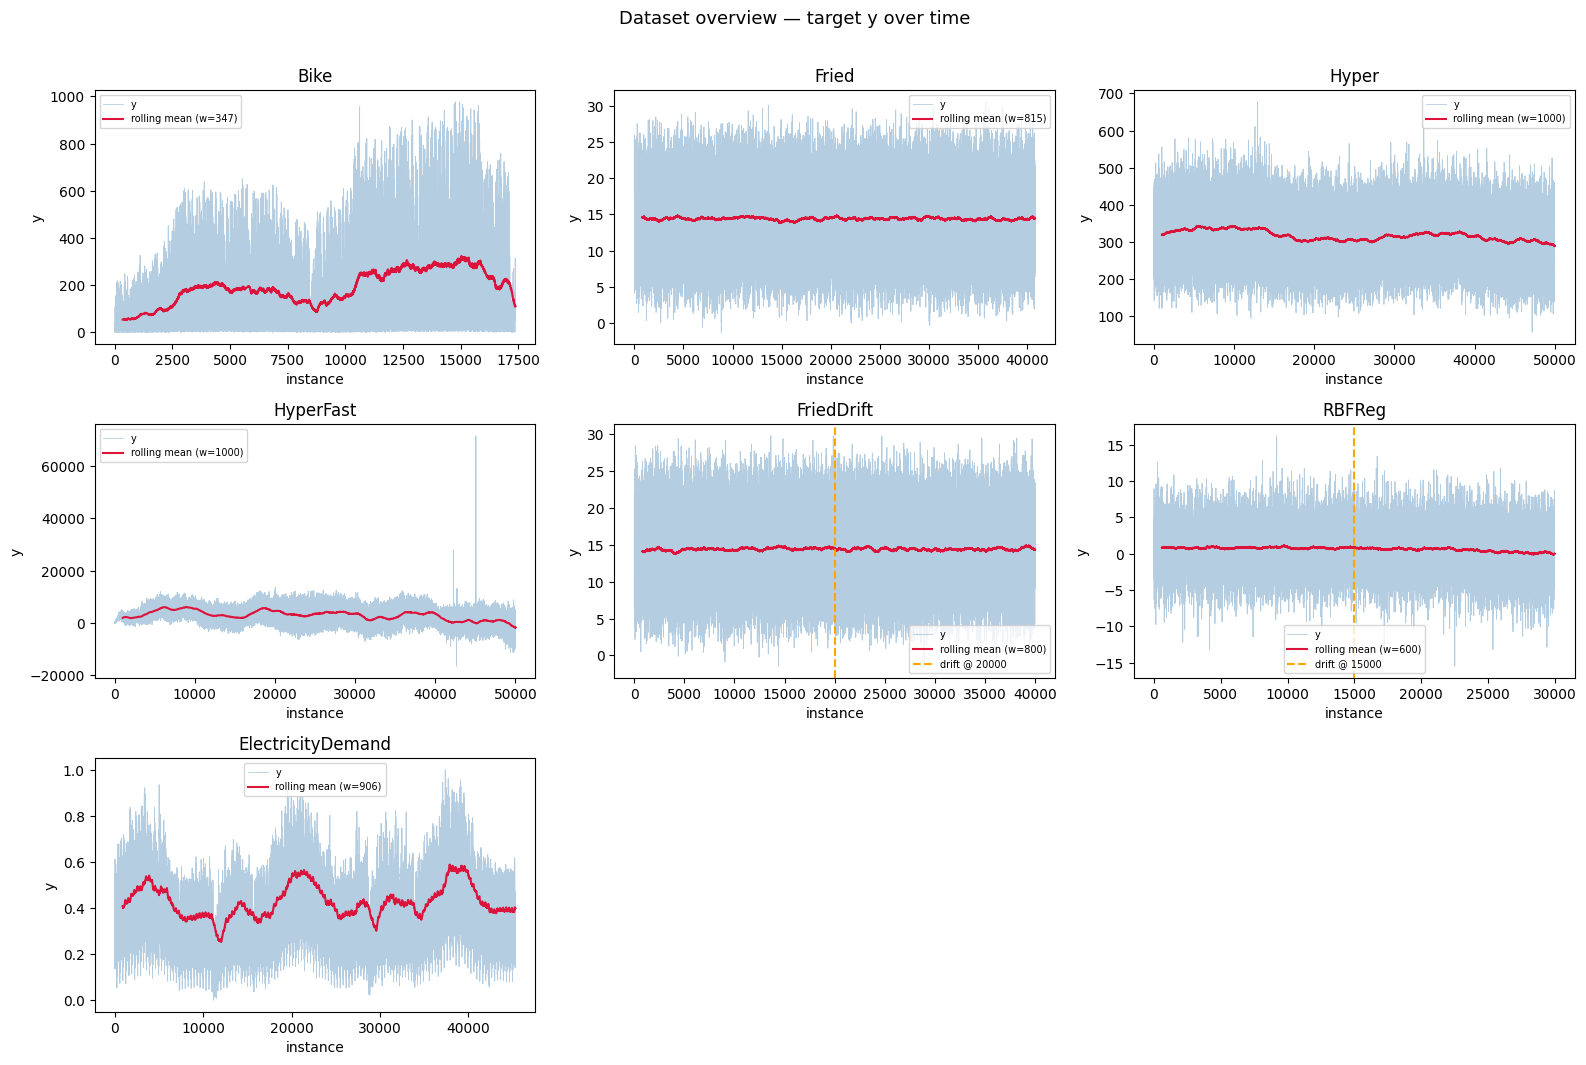

In [4]:
import matplotlib.pyplot as plt
import numpy as np

drift_points = {
    'FriedDrift': 20000,
    'RBFReg':     15000,
}

ncols = 3
nrows = -(-len(datasets) // ncols)  # ceil division
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows))
axes = axes.flatten()

for ax, (name, (X, y, _)) in zip(axes, datasets.items()):
    ax.plot(y, color='steelblue', alpha=0.4, linewidth=0.6, label='y')
    window = max(1, len(y) // 50)
    rolling = np.convolve(y, np.ones(window) / window, mode='valid')
    ax.plot(range(window - 1, len(y)), rolling, color='crimson',
            linewidth=1.5, label=f'rolling mean (w={window})')
    if name in drift_points:
        ax.axvline(drift_points[name], color='orange', linestyle='--',
                   linewidth=1.5, label=f'drift @ {drift_points[name]}')
    ax.set_title(name)
    ax.set_xlabel('instance')
    ax.set_ylabel('y')
    ax.legend(fontsize=7)

for ax in axes[len(datasets):]:
    ax.set_visible(False)

fig.suptitle('Dataset overview — target y over time', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Parametri

In [5]:
BASE = dict(
    grace_period            = 200,
    delta                   = 1e-7,
    tau                     = 0.05,
    leaf_prediction         = 'adaptive',
    bootstrap_sampling      = False,
    model_selector_decay    = 0.95,
    drift_window_threshold  = 500,
    switch_significance     = 0.05,
    min_samples_split       = 5,
    adwin_delta             = 0.0001,
    learning_ratio          = 0.01,
    seed                    = 0,
)

CFG   = {'leaf_prediction': BASE['leaf_prediction'], 'bootstrap_sampling': BASE['bootstrap_sampling']}
SCALE = True
SKIP  = 50

print('Parametri configurati:', BASE)

Parametri configurati: {'grace_period': 200, 'delta': 1e-07, 'tau': 0.05, 'leaf_prediction': 'adaptive', 'bootstrap_sampling': False, 'model_selector_decay': 0.95, 'drift_window_threshold': 500, 'switch_significance': 0.05, 'min_samples_split': 5, 'adwin_delta': 0.0001, 'learning_ratio': 0.01, 'seed': 0}


## Esecuzione

In [6]:
# warmup JVM: evita che il JIT di HotSpot penalizzi il primo dataset (Bike)
_w_X, _w_y, _w_schema = next(iter(datasets.values()))
utils.prequential_eval(_w_X[:10000], _w_y[:10000], 'capy', CFG, BASE, schema=_w_schema, scale=SCALE)

results = {}

for name, (X, y, schema) in datasets.items():
    print(f'{name} — River ...', end=' ', flush=True)
    rp, _, t_p_r, t_t_r, _ = utils.prequential_eval(X, y, 'river', CFG, BASE, scale=SCALE, time_algo=True)
    print(f'{t_p_r + t_t_r:.1f}s | CapyMOA ...', end=' ', flush=True)
    cp, _, t_p_c, t_t_c, _ = utils.prequential_eval(X, y, 'capy', CFG, BASE, schema=schema, scale=SCALE, time_algo=True)
    print(f'{t_p_c + t_t_c:.1f}s')
    results[name] = {'y': y, 'river': rp, 'capy': cp}

print('\nDone.')

Bike — River ... 1.0s | CapyMOA ... 0.5s
Fried — River ... 3.4s | CapyMOA ... 1.1s
Hyper — River ... 4.3s | CapyMOA ... 1.6s
HyperFast — River ... 4.7s | CapyMOA ... 1.5s
FriedDrift — River ... 3.2s | CapyMOA ... 1.4s
RBFReg — River ... 3.5s | CapyMOA ... 1.2s
ElectricityDemand — River ... 2.5s | CapyMOA ... 0.9s

Done.


## Risultati

In [7]:
rows = []
for name, d in results.items():
    yt, rp, cp = d['y'], d['river'], d['capy']
    for fwk, yp in [('River', rp), ('CapyMOA', cp)]:
        rows.append(dict(
            Dataset   = name,
            Framework = fwk,
            N         = len(yt),
            MAE       = utils.mae(yt[SKIP:], yp[SKIP:]),
            RMSE      = utils.rmse(yt[SKIP:], yp[SKIP:]),
            R2        = utils.r2(yt[SKIP:], yp[SKIP:]),
        ))

df = pd.DataFrame(rows).set_index(['Dataset', 'Framework'])
df['MAE']  = df['MAE'].map('{:.4f}'.format)
df['RMSE'] = df['RMSE'].map('{:.4f}'.format)
df['R2']   = df['R2'].map('{:.4f}'.format)
print(df.to_string())

                                 N       MAE      RMSE       R2
Dataset           Framework                                    
Bike              River      17379   69.7574  116.8198   0.5855
                  CapyMOA    17379   69.7574  116.8198   0.5855
Fried             River      40768    1.6362    2.1096   0.8218
                  CapyMOA    40768    1.6362    2.1096   0.8218
Hyper             River      50000    7.9098   14.8632   0.9535
                  CapyMOA    50000    8.4814   15.6607   0.9483
HyperFast         River      50000  286.9853  587.8745   0.9656
                  CapyMOA    50000  287.1021  589.6305   0.9654
FriedDrift        River      40000    1.9312    2.5043   0.7487
                  CapyMOA    40000    1.9312    2.5043   0.7487
RBFReg            River      30000    1.9207    2.5271   0.3096
                  CapyMOA    30000    1.9207    2.5271   0.3096
ElectricityDemand River      45312    0.0517    0.1949  -0.4233
                  CapyMOA    45312    0.

## Curve di apprendimento

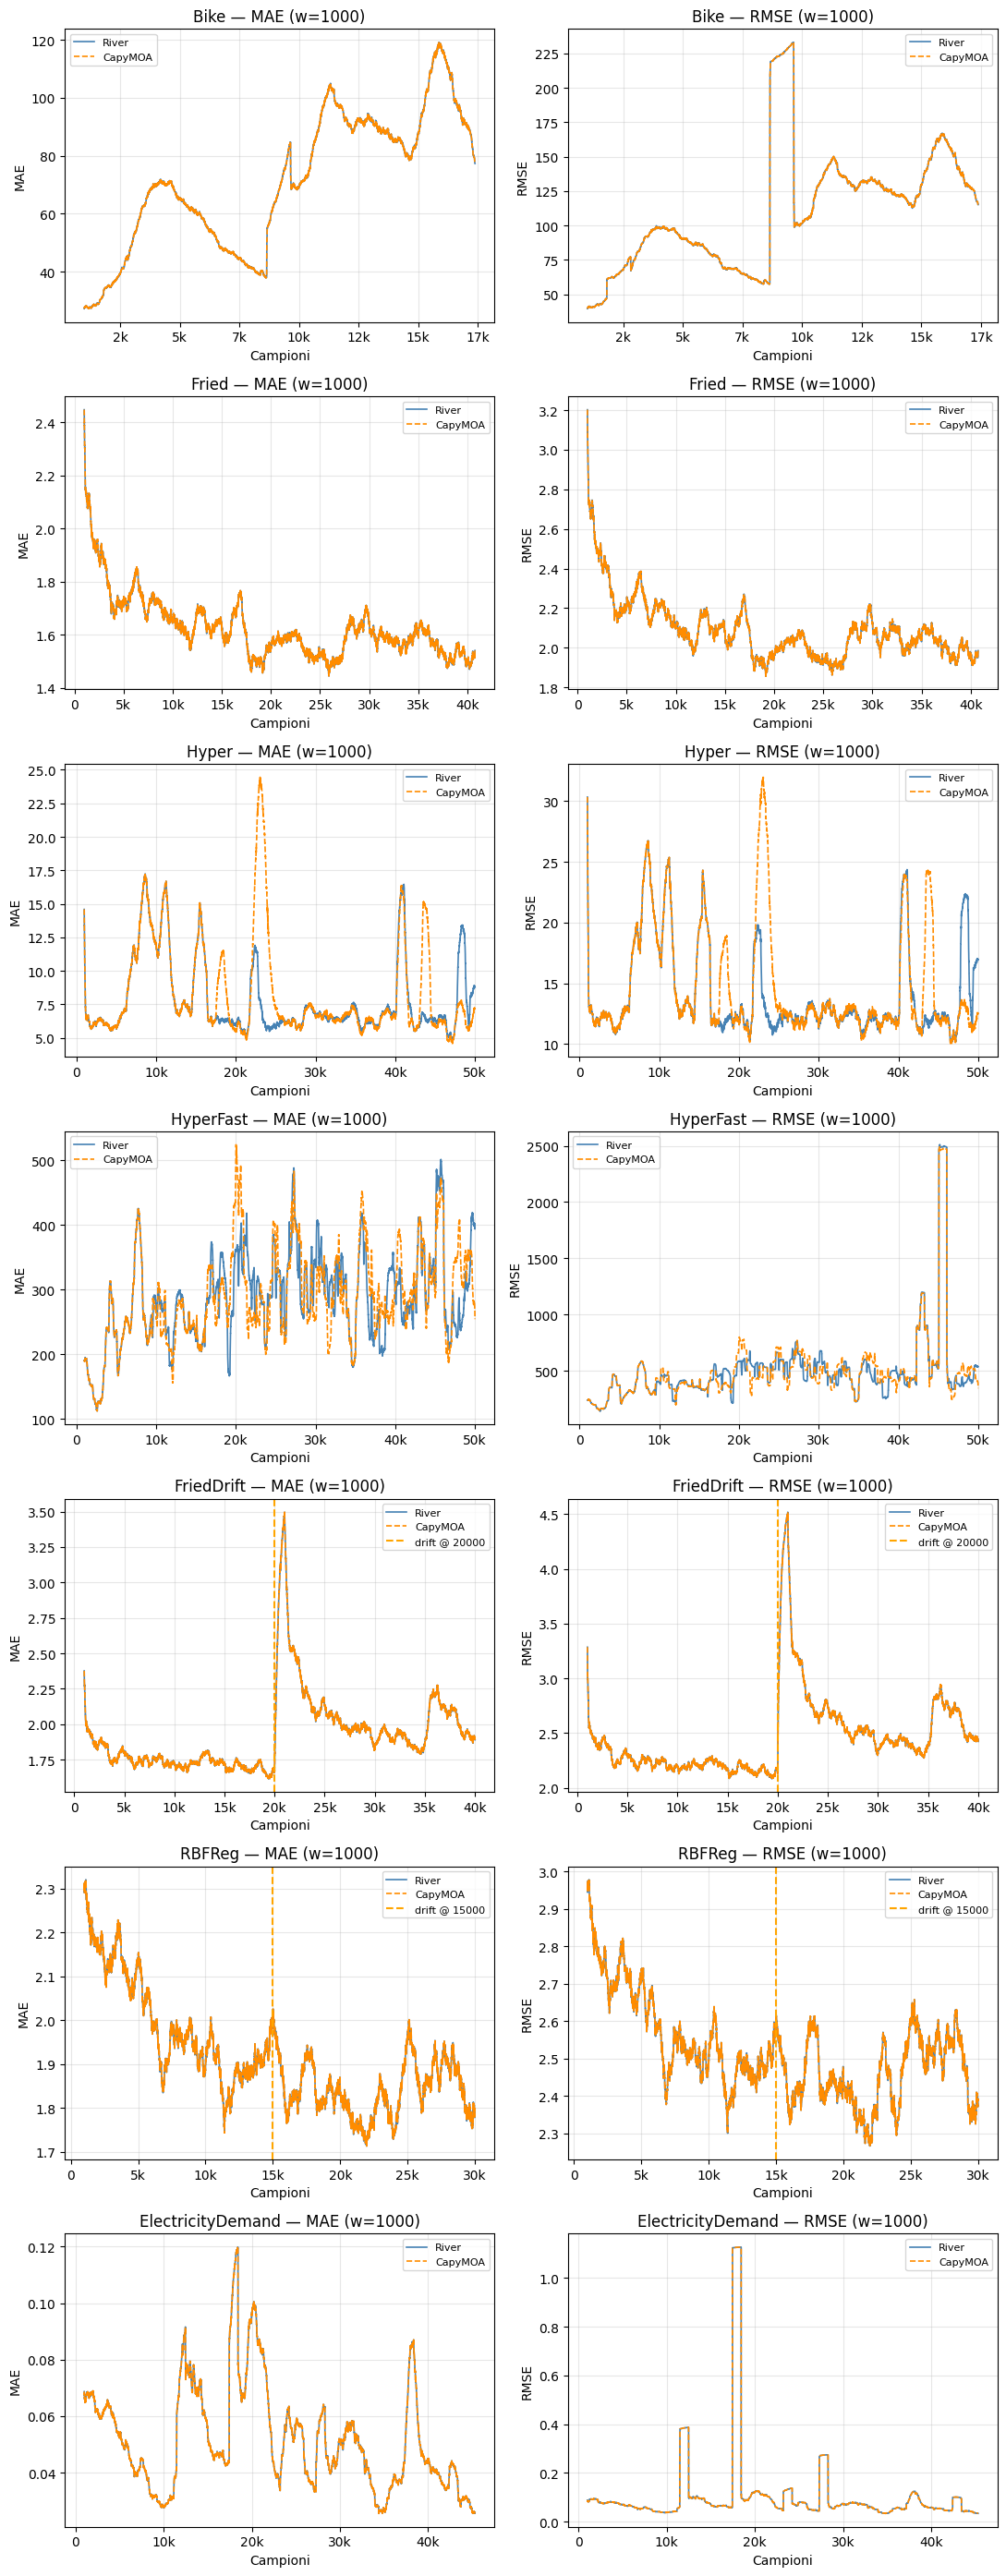

In [10]:
COL_R  = 'steelblue'
COL_C  = 'darkorange'
WINDOW = 1000  # finestra sliding per MAE e RMSE

drift_points = {
    'FriedDrift': 20000,
    'RBFReg':     15000,
}

fig, axes = plt.subplots(len(results), 2, figsize=(11, 4 * len(results)))
if len(results) == 1:
    axes = axes[np.newaxis, :]

for row_idx, (name, d) in enumerate(results.items()):
    yt, rp, cp = d['y'], d['river'], d['capy']
    xs = np.arange(WINDOW - 1, len(yt))

    for col, (metric_fn, ylabel) in enumerate([
        (lambda yt, p: utils.win_mae(yt, p, WINDOW),  'MAE'),
        (lambda yt, p: utils.win_rmse(yt, p, WINDOW), 'RMSE'),
    ]):
        ax = axes[row_idx, col]
        ax.plot(xs, metric_fn(yt, rp), color=COL_R, lw=1.2, label='River')
        ax.plot(xs, metric_fn(yt, cp), color=COL_C, lw=1.2, ls='--', label='CapyMOA')
        if name in drift_points:
            ax.axvline(drift_points[name], color='orange', linestyle='--',
                       linewidth=1.5, label=f'drift @ {drift_points[name]}')
        ax.set(title=f'{name} — {ylabel} (w={WINDOW})', xlabel='Campioni', ylabel=ylabel)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda v, _: f'{int(v/1000)}k' if v >= 1000 else str(int(v))))

plt.tight_layout()
plt.show()